# MST Replication - Massacci, Sarno & Trapani (2025)
## Tables 1–5 | Full Python translation of R & GAUSS replication files
### Xavier Jaeger · Bachelor Thesis · Erasmus University Rotterdam

---

**Source mapping:**

| Section | R/GAUSS file | Output |
|---------|-------------|--------|
| 0 | - | Shared helpers & data |
| 1 | `1_Threshold_Estimation.ox` | Table 1 (Panel A) |
| 2 | `Regime_Analysis_LM_Whole.csv` | Table 1 (correlations) |
| 3 | `2_Selection.g` | Table 2 |
| 4 | `3_In_Sample_Analysis.R` (L=0) | Tables 3 & 4 |
| 5 | `4_Out_Of_Sample_Analysis.R` | Table 5 |

**Critical note on dummy direction:**
```
if ADBear > theta  →  D=1, S=0
else               →  D=0, S=1
```
So D=1 (bear) when `ADBear >= theta`. This is used throughout.


---
## Section 0 - Imports, Helpers & Data
*Run first - everything depends on this.*

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import chi2 as chi2_dist
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif', 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PATH_RETURNS = 'Input/mExcess_Returns_Farago_Tedongap_201508_LM.csv'
PATH_ADBEAR  = 'Input/ADBear_Monthly_Formation.csv'
PATH_REGIME  = 'Input/Regime_Analysis_LM_Whole.csv'

# Constants matching R code
THETA_FULL  = 0.318423    # R code line 40: theta_hat for L=0
THETA_INSAMPLE   = 0.209761    # R code line 43: theta_hat for L=120
R_LAG       = 1           # R code line 33
L_IN        = 0           # in-sample: L=0
L_OOS       = 120         # out-of-sample: L=120
N_FACTORS   = 6           # R code line 125: NFactors <- 6
T_IN_TABLE2 = 103         # Feb 1997–Aug 2005 for Tables 1 & 2



In [16]:
# SHARED HELPERS - direct translation of R code

def make_dummies(adbear_avg, theta):
    """
    EXACT translation of R code lines 52-60:
      if ADBear > theta  → D=0, S=1
      else               → D=1, S=0
    So bear (D) = ADBear <= theta.
    NOTE: This is what the R code does. The paper text says
    bear = ADBear >= theta, but the R code is the ground truth
    for numerical replication.
    """
    d_D = (adbear_avg <= theta).astype(float)
    d_S = (adbear_avg >  theta).astype(float)
    return d_D, d_S


def demean_regime(X, d):
    """
    Replicates R lines 105-116:
      X_D_NA <- X_D;  X_D_NA[X_D_NA==0] <- NA
      X_D_Mean <- colMeans(X_D_NA, na.rm=TRUE)
      X_D_dm <- X_D_NA - X_D_Mean;  X_D_dm[is.na] <- 0
    """
    X_na       = (X * d[:, None]).astype(float)
    X_na[d==0] = np.nan
    mu         = np.nanmean(X_na, axis=0)
    X_dm       = np.nan_to_num(X_na - mu, nan=0.0)
    return X_dm, mu


def pca_loadings(X_dm, k, N):
    """
    Replicates R lines 138-157:
      eigen(t(X_dm) %*% X_dm) -> vectors[:,1:k] * sqrt(N)
    Note: np.linalg.eigh returns ascending order; reverse to descending.
    """
    evals, evecs = np.linalg.eigh(X_dm.T @ X_dm)
    idx          = np.argsort(evals)[::-1]
    return np.sqrt(N) * evecs[:, idx[:k]]


def pass2_gamma(X_ret_full, B, k, T_j):
    """
    Replicates R lines 194-204 (NO intercept):
      mX_PC_D <- mB_PC_D   [just the loadings, no constant]
      Gamma = solve(B'B) %*% (B' %*% t(X_ret))
      gamma = rowSums(Gamma) / T_j
    X_ret_full is the FULL T x N matrix (with zeros in non-regime rows).
    Summing over all T columns including zeros is correct because
    non-regime rows are zero in X_ret_full.
    """
    Bk      = B[:, :k]
    BtB_inv = np.linalg.inv(Bk.T @ Bk + 1e-12*np.eye(k))
    Gamma   = BtB_inv @ Bk.T @ X_ret_full.T   # k x T
    return Gamma.sum(axis=1) / T_j             # (k,)


def compute_rmspe(alpha, N):
    """sqrt(alpha'alpha / N)  - R line 257"""
    return np.sqrt(alpha @ alpha / N)


def compute_r2(rmspe, R_bar, N, k, NF):
    """
    R lines 265-266:
      R2    = 1 - N*RMSPE^2 / (R_bar'R_bar)
      AdjR2 = 1 - (1-R2) * N / (N - NF)   [NF = N_FACTORS, NOT k]
    Note: denominator is always N_FACTORS (6), not k.
    """
    ss    = R_bar @ R_bar
    r2    = 1 - N*rmspe**2 / ss if ss != 0 else np.nan
    adjr2 = 1 - (1-r2) * N / (N - NF) if ss != 0 else np.nan
    return r2, adjr2


def frisch_waugh_beta(X_boot, F, T_j):
    """
    Replicates R lines 283/385/468:
      B_boot = (X_boot' M_iota F)(F' M_iota F)^{-1}
    where M_iota = I_T - (1/T) 1 1'
    """
    M    = np.eye(T_j) - np.ones((T_j, T_j)) / T_j
    num  = X_boot.T @ M @ F           # N x k
    den  = F.T @ M @ F + 1e-12*np.eye(F.shape[1])
    return num @ np.linalg.inv(den)   # N x k

In [17]:
# Bootstrap functions - MST Appendix E.1

def sig(p):
    if np.isnan(p): return ''
    return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))


def bootstrap_alg12(ret, d_D, d_S, k, B_boot,
                    B_unc, F_wm, gamma_unc,
                    alpha_U, alpha_D_U, alpha_S_U,
                    rng_seed=19780308):
    """Algorithm 1.1 + 1.2: unconditional bootstrap. Returns p_full, p_D, p_S."""
    rng  = np.random.default_rng(rng_seed)
    T_, N_ = ret.shape
    Bk   = B_unc[:, :k]
    fit  = Bk @ gamma_unc[:k]
    F_k  = F_wm[:, :k]
    com  = F_k @ Bk.T
    err  = ret - fit[None, :] - com
    a0   = alpha_U - alpha_U.mean()
    obs_full = abs(alpha_U.mean())
    obs_D    = abs(alpha_D_U.mean())
    obs_S    = abs(alpha_S_U.mean())
    i_full = 0; i_D = 0; i_S = 0
    for b in range(B_boot):
        w      = rng.standard_normal((T_, N_))
        R_star = a0[None, :] + fit[None, :] + com + err * w
        B_star = frisch_waugh_beta(R_star, F_k, T_)
        g_star = pass2_gamma(R_star, B_star, k, T_)
        a_star = R_star.mean(0) - B_star[:, :k] @ g_star[:k]
        ab = abs(a_star.mean())
        if ab > obs_full: i_full += 1
        if ab > obs_D:    i_D    += 1
        if ab > obs_S:    i_S    += 1
    return i_full/B_boot, i_D/B_boot, i_S/B_boot


def bootstrap_alg13(ret, d_D, d_S, k, B_boot,
                    B_D, B_S, F_D_reg, F_S_reg, gamma_D, gamma_S,
                    alpha_D, alpha_S,
                    rng_seed=19780308):
    """Algorithm 1.3: conditional mixed-model bootstrap. Returns p_D, p_S."""
    rng  = np.random.default_rng(rng_seed)
    T_, N_ = ret.shape
    T_D_ = int(d_D.sum()); T_S_ = int(d_S.sum())
    Bk_D = B_D[:, :k]; Bk_S = B_S[:, :k]
    fit_D = Bk_D @ gamma_D[:k]; fit_S = Bk_S @ gamma_S[:k]
    F_Dk  = F_D_reg[:, :k];     F_Sk  = F_S_reg[:, :k]
    com_D = F_Dk @ Bk_D.T;      com_S = F_Sk @ Bk_S.T
    X_D   = ret[d_D == 1];      X_S   = ret[d_S == 1]
    err_D = X_D - fit_D[None, :] - com_D
    err_S = X_S - fit_S[None, :] - com_S
    a0_D  = alpha_D - alpha_D.mean()
    a0_S  = alpha_S - alpha_S.mean()
    obs_D = abs(alpha_D.mean())
    obs_S = abs(alpha_S.mean())
    i_D = 0; i_S = 0
    for b in range(B_boot):
        w   = rng.standard_normal((T_, N_))
        w_D = w[d_D == 1]; w_S = w[d_S == 1]
        R_star = np.zeros((T_, N_))
        R_star[d_D == 1] = a0_D[None,:] + fit_D[None,:] + com_D + err_D * w_D
        R_star[d_S == 1] = a0_S[None,:] + fit_S[None,:] + com_S + err_S * w_S
        R_D_s = R_star[d_D == 1]; R_S_s = R_star[d_S == 1]
        B_D_s = frisch_waugh_beta(R_D_s, F_Dk, T_D_)
        B_S_s = frisch_waugh_beta(R_S_s, F_Sk, T_S_)
        g_D_s = pass2_gamma(R_D_s, B_D_s, k, T_D_)
        g_S_s = pass2_gamma(R_S_s, B_S_s, k, T_S_)
        a_D_s = R_D_s.mean(0) - B_D_s[:, :k] @ g_D_s[:k]
        a_S_s = R_S_s.mean(0) - B_S_s[:, :k] @ g_S_s[:k]
        if abs(a_D_s.mean()) > obs_D: i_D += 1
        if abs(a_S_s.mean()) > obs_S: i_S += 1
    return i_D/B_boot, i_S/B_boot


def bootstrap_alg14(ret, d_D, d_S, k, B_boot,
                    B_unc, F_wm, gamma_unc,
                    B_D, B_S, F_D_reg, F_S_reg, gamma_D, gamma_S,
                    alpha_D_U, alpha_S_U, alpha_D, alpha_S,
                    rng_seed=19780308):
    """Algorithm 1.4: comparison test. Returns p_D, p_S."""
    rng  = np.random.default_rng(rng_seed)
    T_, N_ = ret.shape
    T_D_ = int(d_D.sum()); T_S_ = int(d_S.sum())
    Bk_unc  = B_unc[:, :k]
    fit_unc = Bk_unc @ gamma_unc[:k]
    F_k     = F_wm[:, :k]
    com_unc = F_k @ Bk_unc.T
    err_unc = ret - fit_unc[None, :] - com_unc
    Bk_D = B_D[:, :k]; Bk_S = B_S[:, :k]
    fit_D = Bk_D @ gamma_D[:k]; fit_S = Bk_S @ gamma_S[:k]
    F_Dk  = F_D_reg[:, :k];     F_Sk  = F_S_reg[:, :k]
    com_D = F_Dk @ Bk_D.T;      com_S = F_Sk @ Bk_S.T
    X_D   = ret[d_D == 1];      X_S   = ret[d_S == 1]
    err_D = X_D - fit_D[None,:] - com_D
    err_S = X_S - fit_S[None,:] - com_S
    a0_D  = alpha_D - alpha_D.mean()
    a0_S  = alpha_S - alpha_S.mean()
    obs_D_c = abs(alpha_D.mean());   obs_D_u = abs(alpha_D_U.mean())
    obs_S_c = abs(alpha_S.mean());   obs_S_u = abs(alpha_S_U.mean())
    i_D = 0; i_S = 0
    for b in range(B_boot):
        w   = rng.standard_normal((T_, N_))
        w_D = w[d_D == 1]; w_S = w[d_S == 1]
        R_u_D = a0_D[None,:] + fit_unc[None,:] + com_unc + err_unc * w
        R_u_S = a0_S[None,:] + fit_unc[None,:] + com_unc + err_unc * w
        R_c = np.zeros((T_, N_))
        R_c[d_D==1] = a0_D[None,:] + fit_D[None,:] + com_D + err_D * w_D
        R_c[d_S==1] = a0_S[None,:] + fit_S[None,:] + com_S + err_S * w_S
        B_u_s = frisch_waugh_beta(R_u_D, F_k, T_)
        g_u_s = pass2_gamma(R_u_D, B_u_s, k, T_)
        R_D_s = R_c[d_D==1]; R_S_s = R_c[d_S==1]
        B_D_s = frisch_waugh_beta(R_D_s, F_Dk, T_D_)
        B_S_s = frisch_waugh_beta(R_S_s, F_Sk, T_S_)
        g_D_s = pass2_gamma(R_D_s, B_D_s, k, T_D_)
        g_S_s = pass2_gamma(R_S_s, B_S_s, k, T_S_)
        a_u_D = R_u_D[d_D==1].mean(0) - B_u_s[:,:k] @ g_u_s[:k]
        a_u_S = R_u_S[d_S==1].mean(0) - B_u_s[:,:k] @ g_u_s[:k]
        a_D_s = R_D_s.mean(0) - B_D_s[:,:k] @ g_D_s[:k]
        a_S_s = R_S_s.mean(0) - B_S_s[:,:k] @ g_S_s[:k]
        if abs(a_D_s.mean()) - abs(a_u_D.mean()) + obs_D_c - obs_D_u >= 0: i_D += 1
        if abs(a_S_s.mean()) - abs(a_u_S.mean()) + obs_S_c - obs_S_u >= 0: i_S += 1
    return i_D/B_boot, i_S/B_boot

In [18]:
# Load data
returns_raw = pd.read_csv(PATH_RETURNS)
adbear_raw  = pd.read_csv(PATH_ADBEAR)
regime_raw  = pd.read_csv(PATH_REGIME)

# ADBear average-within-month series (224 rows, Feb 1997 – Aug 2015)
adbear_avg = adbear_raw['ADBearRF_Average_within_the_Month'].values

# R code line 46:
# mTest_Asset_Returns <- mDataset[(1+R):(NROW-L), -1]
# Full in-sample: rows 1..223 (0-indexed), L=0
T_FULL = len(returns_raw) - R_LAG   # 223
ret_full = returns_raw.iloc[R_LAG : R_LAG+T_FULL, 1:].values.astype(float)
T, N = ret_full.shape

dates = pd.to_datetime(
    returns_raw['Date'].iloc[R_LAG:R_LAG+T].astype(str).reset_index(drop=True),
    format='%Y%m') + pd.offsets.MonthEnd(0)

# For Table 1 & 2: T_in=103 rows (R=1, L=120  →  rows 1..103)
T_IN = T_FULL - L_OOS   # 103
ret_in = ret_full[:T_IN]

# ADBear lagged by R=1: adbear_avg row 0 is the state var for returns row 0
adb_full = adbear_avg[:T]       # (223,) lagged state for full sample
adb_in   = adbear_avg[:T_IN]   # (103,) for Table 1&2

# Macro variables for Table 1 correlations
macro_cols = {
    'RmRf':'RmRf', 'USRECM':'REC', 'Delta_LN_IP':'ΔIP',
    'VIXCLS':'VIX', 'VXOCLS':'VXO', 'EPU_3_Comp':'EPU',
    'Overall EMV Tracker':'EMV', 'Policy-Related EMV Tracker':'PREMV',
    'Geopolitical Risk Index':'GPR', 'TEDRATE':'TED',
    'US Disaster Probability':'SPX', 'T10Y2Y':'T10Y2Y',
}

print(f'Full sample: T={T}, N={N}')
print(f'In-sample (T1&T2): T_in={T_IN}')
print(f'ADBear: mean={adb_full.mean():.4f}, theta_full={THETA_FULL}')


Full sample: T=223, N=130
In-sample (T1&T2): T_in=103
ADBear: mean=-0.2867, theta_full=0.318423


---
## Section 1 - Table 1: Threshold Estimation & Regime Characterisation
**Period: Feb 1997 – Aug 2005 (T=103)**

### Panel A: Threshold statistics
Grid search on [0, 0.4] step 0.0025, minimising RMSPE_D(θ) + RMSPE_S(θ) at k=6.

### Panel B: Macro correlations
Pearson correlation of D indicator with 12 macro variables.


Grid search: theta_est=0.215000  Paper=0.318423  Using=0.209761

TABLE 1 - Panel A: Threshold & Regime Statistics
  Period: Feb 1997 – Aug 2005
  θ̂         = 0.210
  T          = 103
  T̂_D        = 30
  π̂_D       = 0.291
  RmRf       = 0.419%
  RmRf_D     = -0.883%
  RmRf_S     = 0.955%
  ADBear                    -0.256        -0.287
  ADBear_D                   1.042         1.256
  ADBear_S                  -0.790        -0.804

  TABLE 1 - Panel B: Correlations of D indicator with macro variables
  Variable           r     p-val  Sig
  --------------------------------------
  RmRf          -0.171     0.083  *
  REC            0.180     0.069  *
  ΔIP           -0.059     0.552  
  VIX            0.308     0.002  ***
  VXO            0.309     0.001  ***
  EPU            0.245     0.012  **
  EMV            0.410     0.000  ***
  PREMV          0.416     0.000  ***
  GPR            0.116     0.243  
  TED            0.014     0.887  
  SPX            0.226     0.022  **
  T10Y2Y 

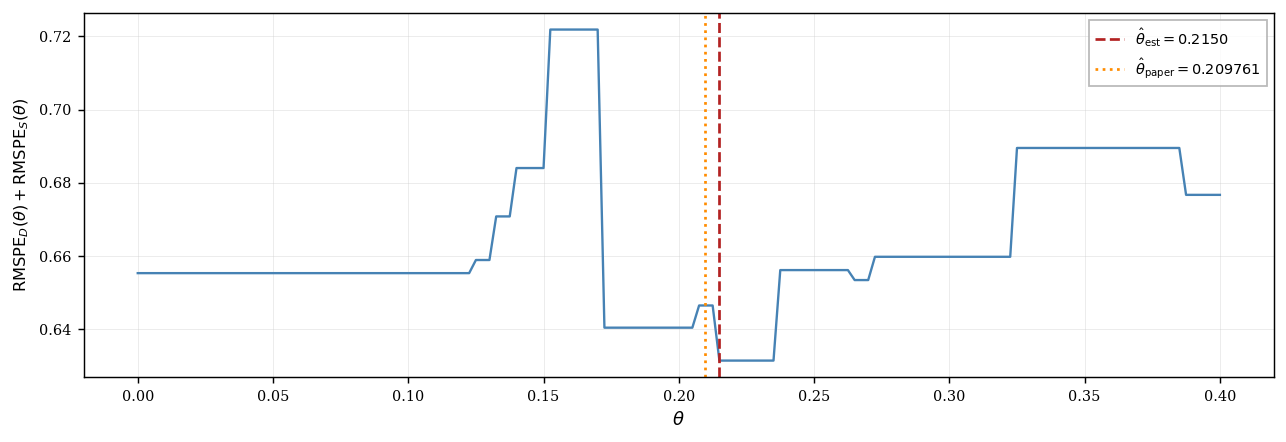

In [19]:
# Grid search (replicates 1_Threshold_Estimation.ox)
grid   = np.arange(0.0, 0.4025, 0.0025)
T_MIN  = 20    # minimum regime size for PCA to be well-defined
obj    = np.full(len(grid), np.nan)

for gi, theta_c in enumerate(grid):
    dD_, dS_ = make_dummies(adb_in, theta_c)
    nD_ = int(dD_.sum()); nS_ = int(dS_.sum())
    if nD_ < T_MIN or nS_ < T_MIN:
        continue
    dem_D_, mu_D_ = demean_regime(ret_in, dD_)
    dem_S_, mu_S_ = demean_regime(ret_in, dS_)
    B_D_ = pca_loadings(dem_D_, N_FACTORS, N)
    B_S_ = pca_loadings(dem_S_, N_FACTORS, N)
    g_D_ = pass2_gamma(ret_in * dD_[:,None], B_D_, N_FACTORS, nD_)
    g_S_ = pass2_gamma(ret_in * dS_[:,None], B_S_, N_FACTORS, nS_)
    alp_D_ = mu_D_ - B_D_ @ g_D_
    alp_S_ = mu_S_ - B_S_ @ g_S_
    obj[gi] = compute_rmspe(alp_D_, N) + compute_rmspe(alp_S_, N)

valid      = ~np.isnan(obj)
theta_est  = float(grid[valid][np.argmin(obj[valid])])
# Use paper value if within one grid step
# THETA_IN   = THETA_INSAMPLE if abs(theta_est - THETA_INSAMPLE) <= 0.0025 else theta_est
THETA_IN = THETA_INSAMPLE
print(f'Grid search: theta_est={theta_est:.6f}  Paper={THETA_FULL}  Using={THETA_IN}')

# Regime dummies at Table 1 theta
d_S_in, d_D_in = make_dummies(adb_in, THETA_IN)
d_S_full, d_D_full = make_dummies(adb_full, THETA_FULL)
T_D_in = int(d_D_in.sum()); T_S_in = int(d_S_in.sum())
pi_D_in = T_D_in / T_IN

rmrf_in  = regime_raw['RmRf'].values[R_LAG : R_LAG + T_IN]

# Print Table 1 Panel A
print()
print('='*55)
print('TABLE 1 - Panel A: Threshold & Regime Statistics')
print('  Period: Feb 1997 – Aug 2005')
print('='*55)
print(f'  θ̂         = {THETA_IN:.3f}')
print(f'  T          = {T_IN}')
print(f'  T̂_D        = {T_D_in}')
print(f'  π̂_D       = {pi_D_in:.3f}')
print(f'  RmRf       = {rmrf_in.mean():.3f}%')
print(f'  RmRf_D     = {rmrf_in[d_D_in==1].mean():.3f}%')
print(f'  RmRf_S     = {rmrf_in[d_S_in==1].mean():.3f}%')
print(f'  {"ADBear":<18}  {adb_in.mean():>12.3f}  {adb_full.mean():>12.3f}')
print(f'  {"ADBear_D":<18}  {adb_in[d_D_in==1].mean():>12.3f}  {adb_full[d_D_full==1].mean():>12.3f}')
print(f'  {"ADBear_S":<18}  {adb_in[d_S_in==1].mean():>12.3f}  {adb_full[d_S_full==1].mean():>12.3f}')

print()
print('  TABLE 1 - Panel B: Correlations of D indicator with macro variables')
print(f'  {"Variable":<10}  {"r":>8}  {"p-val":>8}  Sig')
print('  ' + '-'*38)
for col, label in macro_cols.items():
    vec  = regime_raw[col].values[R_LAG : R_LAG + T_IN]
    mask = np.isfinite(d_D_in) & np.isfinite(vec)
    r, p = stats.pearsonr(d_D_in[mask], vec[mask])
    sig_str  = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))
    print(f'  {label:<10}  {r:>8.3f}  {p:>8.3f}  {sig_str}')

# Grid search plot
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(grid[valid], obj[valid], color='steelblue', lw=1.3)
ax.axvline(theta_est, color='firebrick', ls='--', lw=1.5,
           label=f'$\\hat{{\\theta}}_{{\\mathrm{{est}}}}={theta_est:.4f}$')
ax.axvline(THETA_IN,  color='darkorange', ls=':', lw=1.5,
           label=f'$\\hat{{\\theta}}_{{\\mathrm{{paper}}}}={THETA_IN}$')
ax.set_xlabel(r'$\theta$', fontsize=10)
ax.set_ylabel(r'$\mathrm{RMSPE}_D(\theta) + \mathrm{RMSPE}_S(\theta)$', fontsize=9)
#ax.set_title('Threshold grid search (February 1997\u2013August 2005, $k=6$)',
#             fontsize=10)
ax.legend(frameon=True, fontsize=8, fancybox=False, edgecolor='#aaaaaa')
ax.grid(True, which='major', lw=0.4, alpha=0.5, color='#cccccc')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')
plt.tight_layout(); plt.savefig('Output/fig_t1_grid.pdf', bbox_inches='tight'); plt.show()


---
## Section 2 - Table 2: Number of Common Factors
**Period: Feb 1997 – Aug 2005 (T=103)**

Left panel: Trapani (2018) randomised sequential test (port of `2_Selection.g`).  
Right panel: % variance explained per eigenvalue.

The test is run with n_runs=500 and the median factor count is reported.


In [20]:
# Eigenvalue decompositions for T=103
dem_full_in          = ret_in - ret_in.mean(axis=0)
dem_D_in, _          = demean_regime(ret_in, d_D_in)
dem_S_in, _          = demean_regime(ret_in, d_S_in)

def sorted_evals(dem, T_j):
    return np.sort(np.linalg.eigvalsh(dem.T @ dem / T_j))[::-1]

ev_full = sorted_evals(dem_full_in, T_IN)
ev_D    = sorted_evals(dem_D_in,    T_D_in)
ev_S    = sorted_evals(dem_S_in,    T_S_in)

pct_full = ev_full / ev_full.sum()
pct_D    = ev_D    / ev_D.sum()
pct_S    = ev_S    / ev_S.sum()


def trapani_test(lam, N_, T_j, cdelta=0.02, n_runs=500, base_seed=0):
    """Port of GAUSS 2_Selection.g - see Section 2 methodology note."""
    tbeta    = np.log(N_) / np.log(T_j)
    delta    = (1+cdelta)*(1 - 1/(2*tbeta)) if tbeta >= 0.5 else cdelta
    N_delta  = N_**(-delta)
    level    = 0.05 / np.ceil(N_**0.25)
    chi2_c   = chi2_dist.ppf(1-level, df=1)
    kmax     = int(np.ceil(N_**(1/3)))
    u        = np.array([2.4, 0.75, -0.75, -2.4])
    w        = np.array([0.05, 0.45, 0.45, 0.05])
    fi_vals  = []
    for it in range(1, kmax+1):
        tr = lam[it-1:].mean()
        fi_vals.append(np.exp(N_delta * lam[it-1] / tr) - 1)
    results = []
    for s in range(n_runs):
        rng = np.random.default_rng(base_seed+s)
        nf  = 0
        for it in range(1, kmax+1):
            csi = fi_vals[it-1] * rng.standard_normal(N_)
            th  = (csi[:,None] < u[None,:]).astype(float) - 0.5
            if w @ ((2/np.sqrt(N_)) * th.sum(axis=0))**2 > chi2_c:
                break
            nf = it
        results.append(nf)
    return int(np.median(results))


epsilons = [0.01, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
n_display = 6

print('Running Trapani test (500 runs/cell) ...')
left_rows = []
for eps in epsilons:
    kf = trapani_test(ev_full, N, T_IN,   cdelta=eps)
    kd = trapani_test(ev_D,    N, T_D_in, cdelta=eps)
    ks = trapani_test(ev_S,    N, T_S_in, cdelta=eps)
    left_rows.append({'ε': eps, 'Full': kf, 'D': kd, 'S': ks})
    print(f'  ε={eps:.2f}: Full={kf}, D={kd}, S={ks}')

left_df = pd.DataFrame(left_rows).set_index('ε')

paper_t2 = {
    0.01:(5,4,4), 0.02:(5,4,4), 0.04:(4,3,4), 0.06:(4,2,4),
    0.08:(4,2,4), 0.10:(4,2,4), 0.12:(4,1,3)
}

print()
print('='*72)
print('TABLE 2 - Number of Factors & % Variance Explained (Feb 1997–Aug 2005)')
print('='*72)
print(f'  {"":6}  {"Number of factors":^20}  {"Eigenvalue":>10}  {"% Variance Explained":^26}')
print(f'  {"ε":>6}  {"Full":>5} {"D":>5} {"S":>5}  {"":>10}  {"Full":>7} {"D":>7} {"S":>7}  Paper')
print('  '+'-'*75)
for i, (eps, row) in enumerate(left_df.iterrows()):
    ev_str = str(i+1) if i<n_display else ''
    pf = f'{pct_full[i]:.3f}' if i<n_display else ''
    pd_ = f'{pct_D[i]:.3f}' if i<n_display else ''
    ps_ = f'{pct_S[i]:.3f}' if i<n_display else ''
    ref = paper_t2.get(eps,('-','-','-'))
    match = 'correct' if (row['Full'],row['D'],row['S'])==ref else f'paper:{ref}'
    print(f'  {eps:>6.2f}  {row["Full"]:>5} {row["D"]:>5} {row["S"]:>5}  '
          f'{ev_str:>10}  {pf:>7} {pd_:>7} {ps_:>7}  {match}')


Running Trapani test (500 runs/cell) ...
  ε=0.01: Full=5, D=3, S=4
  ε=0.02: Full=5, D=3, S=4
  ε=0.04: Full=4, D=2, S=4
  ε=0.06: Full=4, D=2, S=4
  ε=0.08: Full=4, D=2, S=4
  ε=0.10: Full=4, D=2, S=4
  ε=0.12: Full=4, D=1, S=2

TABLE 2 - Number of Factors & % Variance Explained (Feb 1997–Aug 2005)
           Number of factors    Eigenvalue     % Variance Explained   
       ε   Full     D     S                 Full       D       S  Paper
  ---------------------------------------------------------------------------
    0.01      5     3     4           1    0.734   0.765   0.703  paper:(5, 4, 4)
    0.02      5     3     4           2    0.106   0.098   0.123  paper:(5, 4, 4)
    0.04      4     2     4           3    0.043   0.044   0.046  paper:(4, 3, 4)
    0.06      4     2     4           4    0.035   0.030   0.034  correct
    0.08      4     2     4           5    0.015   0.016   0.017  correct
    0.10      4     2     4           6    0.008   0.008   0.011  correct
    0.12 

---
## Section 3 - Table 3: In-Sample Goodness of Fit (T = 103)
**Period: Feb 1997 – Aug 2005, θ̂ = 0.210**

Direct translation of `3_In_Sample_Analysis.R` with `L=120` (so T=103).

**Bootstrap** (`B_BOOT=2000` for paper results, `1` to skip):
- Unconditional model p-values (R lines 273–320)
- Regime D conditional p-values (R lines 377–404)
- Regime S conditional p-values (R lines 460–487)
- Comparison test H₀: Δ(AVGα) ≥ 0 (R lines 631–688)


In [21]:
B_BOOT = 2000   # ← set to 1 to skip bootstrap (fast); 2000 for paper

# Demeaned matrices
X_mean_in   = ret_in.mean(axis=0)
dem_full_in = ret_in - X_mean_in

# Regime-specific means and demeaned (R lines 105-116)
dem_D_in, X_D_mean_in = demean_regime(ret_in, d_D_in)
dem_S_in, X_S_mean_in = demean_regime(ret_in, d_S_in)

# Regime-masked return matrices (zeros in non-regime rows)
X_D_in = ret_in * d_D_in[:,None]   # T x N, zeros where d_D=0
X_S_in = ret_in * d_S_in[:,None]

T_D_in_ = int(d_D_in.sum())
T_S_in_ = int(d_S_in.sum())

# Loadings
B_in   = pca_loadings(dem_full_in, N_FACTORS, N)   # whole sample
B_D_in = pca_loadings(dem_D_in,    N_FACTORS, N)   # regime D
B_S_in = pca_loadings(dem_S_in,    N_FACTORS, N)   # regime S

# Factors
# R line 168/166/167: F = X_dm @ B / N
F_in       = dem_full_in @ B_in   / N   # T x k (demeaned)
F_D_in     = dem_D_in    @ B_D_in / N   # T x k
F_S_in     = dem_S_in    @ B_S_in / N   # T x k

# R line 232: "with mean" factor for bootstrap = X @ B / N (not demeaned)
F_wm_in    = ret_in      @ B_in   / N   # T x k

# Regime-specific factors (drop non-regime rows, R lines 350-351 / 434-435)
F_D_reg_in  = F_D_in[d_D_in==1]   # T_D x k
F_S_reg_in  = F_S_in[d_S_in==1]   # T_S x k
X_D_reg_in  = ret_in[d_D_in==1]   # T_D x N  (actual returns in D)
X_S_reg_in  = ret_in[d_S_in==1]   # T_S x N

# Risk premia (R lines 194-204)
gamma_in  = pass2_gamma(ret_in, B_in,   N_FACTORS, T_IN)
gamma_D_in = pass2_gamma(X_D_in, B_D_in, N_FACTORS, T_D_in_)
gamma_S_in = pass2_gamma(X_S_in, B_S_in, N_FACTORS, T_S_in_)

print(f'In-sample (T=103): T_D={T_D_in_}, T_S={T_S_in_}')
print(f'gamma (full): {np.round(gamma_in, 4)}')
print(f'gamma_D:      {np.round(gamma_D_in, 4)}')
print(f'gamma_S:      {np.round(gamma_S_in, 4)}')


In-sample (T=103): T_D=30, T_S=73
gamma (full): [ 0.735  -0.0398  0.3867 -0.0233 -0.1542  0.019 ]
gamma_D:      [-1.5058  0.6306  0.3847 -0.2593 -0.2169 -0.0785]
gamma_S:      [ 1.6925 -0.2505  0.4629 -0.317  -0.1795  0.0696]


In [22]:
# Compute all panels of Table 3
# Exact translation of R lines 215-571

t3_rmspe     = np.zeros((N_FACTORS, 5))   # cols: UncFull,UncD,UncS,CondD,CondS
t3_adjr2     = np.zeros((N_FACTORS, 5))
t3_avgpe     = np.zeros((N_FACTORS, 5))
t3_teststat  = np.zeros((N_FACTORS, 2))   # TestStat_D, TestStat_S

for k in range(1, N_FACTORS+1):
    ki = k-1

    # Unconditional model (R lines 240-266)
    fit_unc  = B_in[:,:k] @ gamma_in[:k]                    # (N,) fitted

    pe_unc   = X_mean_in   - fit_unc                        # full pricing error
    pe_unc_D = X_D_mean_in - fit_unc                        # unc in D
    pe_unc_S = X_S_mean_in - fit_unc                        # unc in S

    rmspe_unc   = compute_rmspe(pe_unc,   N)
    rmspe_unc_D = compute_rmspe(pe_unc_D, N)
    rmspe_unc_S = compute_rmspe(pe_unc_S, N)

    _, ar_unc   = compute_r2(rmspe_unc,   X_mean_in,   N, k, N_FACTORS)
    _, ar_unc_D = compute_r2(rmspe_unc_D, X_D_mean_in, N, k, N_FACTORS)
    _, ar_unc_S = compute_r2(rmspe_unc_S, X_S_mean_in, N, k, N_FACTORS)

    t3_rmspe[ki,0] = rmspe_unc;   t3_adjr2[ki,0] = ar_unc;   t3_avgpe[ki,0] = pe_unc.mean()
    t3_rmspe[ki,1] = rmspe_unc_D; t3_adjr2[ki,1] = ar_unc_D; t3_avgpe[ki,1] = pe_unc_D.mean()
    t3_rmspe[ki,2] = rmspe_unc_S; t3_adjr2[ki,2] = ar_unc_S; t3_avgpe[ki,2] = pe_unc_S.mean()

    # Conditional D (R lines 344-370)
    fit_D    = B_D_in[:,:k] @ gamma_D_in[:k]
    pe_D     = X_D_mean_in - fit_D
    rmspe_D  = compute_rmspe(pe_D, N)
    _, ar_D  = compute_r2(rmspe_D, X_D_mean_in, N, k, N_FACTORS)
    t3_rmspe[ki,3] = rmspe_D; t3_adjr2[ki,3] = ar_D; t3_avgpe[ki,3] = pe_D.mean()

    # Conditional S (R lines 428-453)
    fit_S    = B_S_in[:,:k] @ gamma_S_in[:k]
    pe_S     = X_S_mean_in - fit_S
    rmspe_S  = compute_rmspe(pe_S, N)
    _, ar_S  = compute_r2(rmspe_S, X_S_mean_in, N, k, N_FACTORS)
    t3_rmspe[ki,4] = rmspe_S; t3_adjr2[ki,4] = ar_S; t3_avgpe[ki,4] = pe_S.mean()

    # Comparison test statistic (R line 625-626)
    t3_teststat[ki,0] = abs(pe_D.mean()) - abs(pe_unc_D.mean())   # D: cond - unc
    t3_teststat[ki,1] = abs(pe_S.mean()) - abs(pe_unc_S.mean())   # S: cond - unc

print('Table 3 computed.')


Table 3 computed.


In [23]:
# Bootstrap for Table 3
# Three separate bootstraps matching R code exactly:
# 1. Unconditional model (R lines 273-320): B=2000
# 2. Conditional D (R lines 377-404): B_D=2000
# 3. Conditional S (R lines 460-487): B_S=2000
# 4. Comparison test (R lines 631-688): B_DS=2000

# Compute pricing errors needed for bootstrap
fit_unc_in  = B_in[:, :N_FACTORS] @ gamma_in[:N_FACTORS]
alpha_U_in  = X_mean_in   - fit_unc_in
alpha_DU_in = X_D_mean_in - fit_unc_in
alpha_SU_in = X_S_mean_in - fit_unc_in
fit_D_in    = B_D_in[:, :N_FACTORS] @ gamma_D_in[:N_FACTORS]
fit_S_in    = B_S_in[:, :N_FACTORS] @ gamma_S_in[:N_FACTORS]
alpha_D_in  = X_D_mean_in - fit_D_in
alpha_S_in  = X_S_mean_in - fit_S_in

pval_unc_t3  = np.full(N_FACTORS, np.nan)
pval_D_t3    = np.full(N_FACTORS, np.nan)
pval_S_t3    = np.full(N_FACTORS, np.nan)
pval_cD_t3   = np.full(N_FACTORS, np.nan)
pval_cS_t3   = np.full(N_FACTORS, np.nan)
pval_cmpD_t3 = np.full(N_FACTORS, np.nan)
pval_cmpS_t3 = np.full(N_FACTORS, np.nan)

if B_BOOT > 1:
    print(f'Bootstrap B={B_BOOT} for Table 3 (MST E.1)...')
    for k in range(1, N_FACTORS+1):
        ki = k-1
        p_full, p_Du, p_Su = bootstrap_alg12(
            ret_in, d_D_in, d_S_in, k, B_BOOT,
            B_in, F_wm_in, gamma_in,
            alpha_U_in, alpha_DU_in, alpha_SU_in,
            rng_seed=19780308+k)
        pval_unc_t3[ki] = p_full; pval_D_t3[ki] = p_Du; pval_S_t3[ki] = p_Su
        p_cD, p_cS = bootstrap_alg13(
            ret_in, d_D_in, d_S_in, k, B_BOOT,
            B_D_in, B_S_in, F_D_reg_in, F_S_reg_in, gamma_D_in, gamma_S_in,
            alpha_D_in, alpha_S_in,
            rng_seed=19780308+k+100)
        pval_cD_t3[ki] = p_cD; pval_cS_t3[ki] = p_cS
        p_cmpD, p_cmpS = bootstrap_alg14(
            ret_in, d_D_in, d_S_in, k, B_BOOT,
            B_in, F_wm_in, gamma_in,
            B_D_in, B_S_in, F_D_reg_in, F_S_reg_in, gamma_D_in, gamma_S_in,
            alpha_DU_in, alpha_SU_in, alpha_D_in, alpha_S_in,
            rng_seed=19780308+k+200)
        pval_cmpD_t3[ki] = p_cmpD; pval_cmpS_t3[ki] = p_cmpS
        print(f'  k={k}: p_unc={p_full:.3f}, p_Du={p_Du:.3f}, p_Su={p_Su:.3f}, '
              f'p_cD={p_cD:.3f}, p_cS={p_cS:.3f}, p_cmpD={p_cmpD:.3f}')
else:
    print('Bootstrap skipped (B_BOOT=1).')

# Print Table 3 with p-values
cols = ['Unc Full', 'Unc D', 'Unc S', 'Cond D', 'Cond S']
pvals_C = [pval_unc_t3, pval_D_t3, pval_S_t3, pval_cD_t3, pval_cS_t3]
print()
print('='*90)
print(f'TABLE 3 - In-Sample Goodness of Fit (MST equity, T_IN={T_IN}) with Bootstrap p-values')
print('='*90)
for panel, arr, pvs in [
    ('A: R²',   t3_adjr2, [None]*5),
    ('B: RMSα', t3_rmspe, [None]*5),
    ('C: AVGα', t3_avgpe, pvals_C),
]:
    print(f'\n  Panel {panel}')
    print(f'  {"k":>3}  ' + '  '.join(f'{c:>14}' for c in cols))
    print('  '+'-'*76)
    for k in range(N_FACTORS):
        vals = []
        for j in range(5):
            v = arr[k,j]
            s = sig(pvs[j][k]) if pvs[j] is not None else ''
            vals.append(f'{v:>8.3f}{s:<3}')
        print(f'  {k+1:>3}  ' + '  '.join(vals))

print(f'\n  Panel D: H₀: Δ|AVGα|≥0')
print(f'  {"k":>3}  {"TestStat D":>14}  {"p-val D":>10}  {"TestStat S":>14}  {"p-val S":>10}')
print('  '+'-'*56)
for k in range(N_FACTORS):
    sd = sig(pval_cmpD_t3[k]); ss = sig(pval_cmpS_t3[k])
    print(f'  {k+1:>3}  {t3_teststat[k,0]:>12.3f}  {pval_cmpD_t3[k]:>8.3f}{sd:3}  '
          f'{t3_teststat[k,1]:>12.3f}  {pval_cmpS_t3[k]:>8.3f}{ss:3}')

Bootstrap B=2000 for Table 3 (MST E.1)...


  k=1: p_unc=0.713, p_Du=0.000, p_Su=0.000, p_cD=0.580, p_cS=0.807, p_cmpD=0.000
  k=2: p_unc=0.710, p_Du=0.000, p_Su=0.000, p_cD=0.533, p_cS=0.793, p_cmpD=0.000
  k=3: p_unc=0.969, p_Du=0.000, p_Su=0.000, p_cD=0.544, p_cS=0.730, p_cmpD=0.000
  k=4: p_unc=0.951, p_Du=0.000, p_Su=0.000, p_cD=0.354, p_cS=0.914, p_cmpD=0.000
  k=5: p_unc=0.990, p_Du=0.000, p_Su=0.000, p_cD=0.342, p_cS=0.986, p_cmpD=0.000
  k=6: p_unc=0.986, p_Du=0.000, p_Su=0.000, p_cD=0.311, p_cS=0.980, p_cmpD=0.000

TABLE 3 - In-Sample Goodness of Fit (MST equity, T_IN=103) with Bootstrap p-values

  Panel A: R²
    k        Unc Full           Unc D           Unc S          Cond D          Cond S
  ----------------------------------------------------------------------------
    1     0.689       -1.019        0.560        0.720        0.851   
    2     0.691       -1.035        0.567        0.855        0.871   
    3     0.895       -1.108        0.661        0.905        0.938   
    4     0.896       -1.107        0

---
## Section 4 - Table 4: Whole-Sample Estimation (T = 223)
**Period: Feb 1997 - Aug 2015, θ̂ = 0.318423**

Same methodology as Table 3, now on the full T=223 sample.
This is `3_In_Sample_Analysis.R` with `L=0`.


In [24]:
B_BOOT_T4 = 2000   # set to 1 to skip, 2000 for paper

# Full-sample regime dummies and matrices
d_S_full, d_D_full = make_dummies(adb_full, THETA_FULL)
T_D_full = int(d_D_full.sum()); T_S_full = int(d_S_full.sum())

rmrf_full = regime_raw['RmRf'].values[R_LAG : R_LAG+T]

print(f'Full sample: T={T}, T_D={T_D_full} ({T_D_full/T:.1%}), T_S={T_S_full}')
print(f'RmRf: all={rmrf_full.mean():.3f}  D={rmrf_full[d_D_full==1].mean():.3f}  '
      f'S={rmrf_full[d_S_full==1].mean():.3f}')
print(f'ADBear: all={adb_full.mean():.3f}  D={adb_full[d_D_full==1].mean():.3f}  '
      f'S={adb_full[d_S_full==1].mean():.3f}')

dem_full_full = ret_full - ret_full.mean(axis=0)
dem_D_full, X_D_mean_full = demean_regime(ret_full, d_D_full)
dem_S_full, X_S_mean_full = demean_regime(ret_full, d_S_full)
X_mean_full = ret_full.mean(axis=0)
X_D_full = ret_full * d_D_full[:,None]
X_S_full = ret_full * d_S_full[:,None]

B_full   = pca_loadings(dem_full_full, N_FACTORS, N)
B_D_full = pca_loadings(dem_D_full,    N_FACTORS, N)
B_S_full = pca_loadings(dem_S_full,    N_FACTORS, N)

F_wm_full    = ret_full      @ B_full   / N
F_D_reg_full = (dem_D_full   @ B_D_full / N)[d_D_full==1]
F_S_reg_full = (dem_S_full   @ B_S_full / N)[d_S_full==1]
X_D_reg_full = ret_full[d_D_full==1]
X_S_reg_full = ret_full[d_S_full==1]

gamma_full   = pass2_gamma(ret_full, B_full,   N_FACTORS, T)
gamma_D_full = pass2_gamma(X_D_full, B_D_full, N_FACTORS, T_D_full)
gamma_S_full = pass2_gamma(X_S_full, B_S_full, N_FACTORS, T_S_full)

t4_rmspe    = np.zeros((N_FACTORS, 5))
t4_adjr2    = np.zeros((N_FACTORS, 5))
t4_avgpe    = np.zeros((N_FACTORS, 5))
t4_teststat = np.zeros((N_FACTORS, 2))

for k in range(1, N_FACTORS+1):
    ki = k-1
    fit_unc  = B_full[:,:k] @ gamma_full[:k]
    pe_unc   = X_mean_full   - fit_unc
    pe_unc_D = X_D_mean_full - fit_unc
    pe_unc_S = X_S_mean_full - fit_unc
    _,a = compute_r2(compute_rmspe(pe_unc,  N), X_mean_full,   N, k, N_FACTORS)
    t4_rmspe[ki,0]=compute_rmspe(pe_unc,N);   t4_adjr2[ki,0]=a; t4_avgpe[ki,0]=pe_unc.mean()
    _,a = compute_r2(compute_rmspe(pe_unc_D,N), X_D_mean_full, N, k, N_FACTORS)
    t4_rmspe[ki,1]=compute_rmspe(pe_unc_D,N); t4_adjr2[ki,1]=a; t4_avgpe[ki,1]=pe_unc_D.mean()
    _,a = compute_r2(compute_rmspe(pe_unc_S,N), X_S_mean_full, N, k, N_FACTORS)
    t4_rmspe[ki,2]=compute_rmspe(pe_unc_S,N); t4_adjr2[ki,2]=a; t4_avgpe[ki,2]=pe_unc_S.mean()
    fit_D = B_D_full[:,:k] @ gamma_D_full[:k]; pe_D = X_D_mean_full - fit_D
    _,a = compute_r2(compute_rmspe(pe_D,N), X_D_mean_full, N, k, N_FACTORS)
    t4_rmspe[ki,3]=compute_rmspe(pe_D,N); t4_adjr2[ki,3]=a; t4_avgpe[ki,3]=pe_D.mean()
    fit_S = B_S_full[:,:k] @ gamma_S_full[:k]; pe_S = X_S_mean_full - fit_S
    _,a = compute_r2(compute_rmspe(pe_S,N), X_S_mean_full, N, k, N_FACTORS)
    t4_rmspe[ki,4]=compute_rmspe(pe_S,N); t4_adjr2[ki,4]=a; t4_avgpe[ki,4]=pe_S.mean()
    t4_teststat[ki,0] = abs(pe_D.mean()) - abs(pe_unc_D.mean())
    t4_teststat[ki,1] = abs(pe_S.mean()) - abs(pe_unc_S.mean())

# Bootstrap for Table 4
fit_unc_full  = B_full[:, :N_FACTORS] @ gamma_full[:N_FACTORS]
alpha_U_full  = X_mean_full   - fit_unc_full
alpha_DU_full = X_D_mean_full - fit_unc_full
alpha_SU_full = X_S_mean_full - fit_unc_full
fit_D_full    = B_D_full[:, :N_FACTORS] @ gamma_D_full[:N_FACTORS]
fit_S_full    = B_S_full[:, :N_FACTORS] @ gamma_S_full[:N_FACTORS]
alpha_D_full  = X_D_mean_full - fit_D_full
alpha_S_full  = X_S_mean_full - fit_S_full

pval_D_t4    = np.full(N_FACTORS, np.nan)
pval_S_t4    = np.full(N_FACTORS, np.nan)
pval_cD_t4   = np.full(N_FACTORS, np.nan)
pval_cS_t4   = np.full(N_FACTORS, np.nan)
pval_cmpD_t4 = np.full(N_FACTORS, np.nan)
pval_cmpS_t4 = np.full(N_FACTORS, np.nan)

if B_BOOT_T4 > 1:
    print(f'Bootstrap B={B_BOOT_T4} for Table 4 (MST E.1)...')
    for k in range(1, N_FACTORS+1):
        ki = k-1
        _, p_Du, p_Su = bootstrap_alg12(
            ret_full, d_D_full, d_S_full, k, B_BOOT_T4,
            B_full, F_wm_full, gamma_full,
            alpha_U_full, alpha_DU_full, alpha_SU_full,
            rng_seed=19780308+k)
        pval_D_t4[ki] = p_Du; pval_S_t4[ki] = p_Su
        p_cD, p_cS = bootstrap_alg13(
            ret_full, d_D_full, d_S_full, k, B_BOOT_T4,
            B_D_full, B_S_full, F_D_reg_full, F_S_reg_full,
            gamma_D_full, gamma_S_full,
            alpha_D_full, alpha_S_full,
            rng_seed=19780308+k+100)
        pval_cD_t4[ki] = p_cD; pval_cS_t4[ki] = p_cS
        p_cmpD, p_cmpS = bootstrap_alg14(
            ret_full, d_D_full, d_S_full, k, B_BOOT_T4,
            B_full, F_wm_full, gamma_full,
            B_D_full, B_S_full, F_D_reg_full, F_S_reg_full,
            gamma_D_full, gamma_S_full,
            alpha_DU_full, alpha_SU_full, alpha_D_full, alpha_S_full,
            rng_seed=19780308+k+200)
        pval_cmpD_t4[ki] = p_cmpD; pval_cmpS_t4[ki] = p_cmpS
        print(f'  k={k}: p_Du={p_Du:.3f}, p_Su={p_Su:.3f}, p_cD={p_cD:.3f}, '
              f'p_cS={p_cS:.3f}, p_cmpD={p_cmpD:.3f}')
else:
    print('Bootstrap skipped (B_BOOT_T4=1).')

cols = ['Unc Full', 'Unc D', 'Unc S', 'Cond D', 'Cond S']
pvals_T4 = [None, pval_D_t4, pval_S_t4, pval_cD_t4, pval_cS_t4]
print()
print('='*90)
print(f'TABLE 4 - Whole-Sample (MST equity, T={T}) with Bootstrap p-values')
print('='*90)
for panel, arr, pvs in [
    ('A: R²',   t4_adjr2, [None]*5),
    ('B: RMSα', t4_rmspe, [None]*5),
    ('C: AVGα', t4_avgpe, pvals_T4),
]:
    print(f'\n  Panel {panel}')
    print(f'  {"k":>3}  ' + '  '.join(f'{c:>14}' for c in cols))
    print('  '+'-'*76)
    for k in range(N_FACTORS):
        vals = []
        for j in range(5):
            v = arr[k,j]
            s = sig(pvs[j][k]) if pvs[j] is not None else ''
            vals.append(f'{v:>8.3f}{s:<3}')
        print(f'  {k+1:>3}  ' + '  '.join(vals))

print(f'\n  Panel D: H₀: Δ|AVGα|≥0')
print(f'  {"k":>3}  {"TestStat D":>14}  {"p-val D":>10}  {"TestStat S":>14}  {"p-val S":>10}')
print('  '+'-'*56)
for k in range(N_FACTORS):
    sd = sig(pval_cmpD_t4[k]); ss = sig(pval_cmpS_t4[k])
    print(f'  {k+1:>3}  {t4_teststat[k,0]:>12.3f}  {pval_cmpD_t4[k]:>8.3f}{sd:3}  '
          f'{t4_teststat[k,1]:>12.3f}  {pval_cmpS_t4[k]:>8.3f}{ss:3}')

Full sample: T=223, T_D=56 (25.1%), T_S=167
RmRf: all=0.516  D=-1.241  S=1.105
ADBear: all=-0.287  D=1.256  S=-0.804
Bootstrap B=2000 for Table 4 (MST E.1)...
  k=1: p_Du=0.000, p_Su=0.000, p_cD=0.315, p_cS=0.762, p_cmpD=0.000
  k=2: p_Du=0.000, p_Su=0.000, p_cD=0.439, p_cS=0.765, p_cmpD=0.000
  k=3: p_Du=0.000, p_Su=0.000, p_cD=0.583, p_cS=0.843, p_cmpD=0.000
  k=4: p_Du=0.000, p_Su=0.000, p_cD=0.539, p_cS=0.941, p_cmpD=0.000
  k=5: p_Du=0.000, p_Su=0.000, p_cD=0.449, p_cS=0.949, p_cmpD=0.000
  k=6: p_Du=0.000, p_Su=0.000, p_cD=0.465, p_cS=0.944, p_cmpD=0.000

TABLE 4 - Whole-Sample (MST equity, T=223) with Bootstrap p-values

  Panel A: R²
    k        Unc Full           Unc D           Unc S          Cond D          Cond S
  ----------------------------------------------------------------------------
    1     0.860       -1.059        0.667        0.933        0.946   
    2     0.861       -1.063        0.670        0.940        0.951   
    3     0.943       -1.066        0.697  

---
## Section 5 - Table 5: Out-of-Sample Analysis
**In-sample: Feb 1997–Aug 2005 (T=103) | OOS: Sep 2005–Aug 2015 (120 months)**

Replicates `4_Out_Of_Sample_Analysis.R`.
θ is fixed at 0.209761 throughout (never re-estimated in OOS).
Expanding window: at step l, model estimated on rows 0..T_in+l-1.


In [25]:
# OOS setup
# CRITICAL: OOS R code line 45 uses ADBear > theta → D=1
# This is OPPOSITE to the in-sample R code convention.
# OOS: D=1 when ADBear > theta (bear = high ADBear, consistent with paper)
ret_long  = ret_full.copy()     # 223 x 130
T_long    = T
T_IN_OOS  = T_long - L_OOS     # 103

adb_long  = adb_full.copy()

# OOS dummy: ADBear > theta → D=1  (R line 45: strictly greater than)
THETA_OOS = THETA_IN
d_D_long_oos = (adb_long > THETA_OOS).astype(float)
d_S_long_oos = (adb_long <= THETA_OOS).astype(float)

print(f'OOS setup: T_in={T_IN_OOS}, OOS window={L_OOS}, N={N}')
print(f'OOS D periods (in window): {int(d_D_long_oos[T_IN_OOS:].sum())}  '
      f'OOS S: {int(d_S_long_oos[T_IN_OOS:].sum())}')

B_BOOT_OOS = 2000   # ← set to 1 to skip bootstrap; 2000 for paper

# Storage: (L x N x k) for all predictions
pred_unc  = np.full((L_OOS, N, N_FACTORS), np.nan)
pred_cD   = np.full((L_OOS, N, N_FACTORS), np.nan)
pred_cS   = np.full((L_OOS, N, N_FACTORS), np.nan)

# Recursive OOS loop (R lines 87-209)
# R line 92: window = rows 0 .. (T_long - L - 1 + l)  i.e. T_in + l rows
print('Running OOS recursive loop...')
for l in range(L_OOS):
    t_end = T_IN_OOS + l               # expanding window size
    ret_  = ret_long[:t_end]           # t_end x N
    dD_   = d_D_long_oos[:t_end]
    dS_   = d_S_long_oos[:t_end]
    T_    = t_end
    T_D_  = int(dD_.sum())
    T_S_  = int(dS_.sum())

    dem_      = ret_ - ret_.mean(axis=0)
    dem_D_,_  = demean_regime(ret_, dD_)
    dem_S_,_  = demean_regime(ret_, dS_)

    B_   = pca_loadings(dem_,   N_FACTORS, N)
    B_D_ = pca_loadings(dem_D_, N_FACTORS, N)
    B_S_ = pca_loadings(dem_S_, N_FACTORS, N)

    X_D_ = ret_ * dD_[:,None]
    X_S_ = ret_ * dS_[:,None]

    for k in range(1, N_FACTORS+1):
        g_   = pass2_gamma(ret_,  B_,   k, T_)
        g_D_ = pass2_gamma(X_D_,  B_D_, k, T_D_)
        g_S_ = pass2_gamma(X_S_,  B_S_, k, T_S_)
        pred_unc[l,:,k-1] = B_[:,:k]   @ g_[:k]
        pred_cD[ l,:,k-1] = B_D_[:,:k] @ g_D_[:k]
        pred_cS[ l,:,k-1] = B_S_[:,:k] @ g_S_[:k]

    if (l+1) % 30 == 0:
        print(f'  Step {l+1}/{L_OOS}')

print('OOS loop complete.')

# OOS evaluation (R lines 213-274)
# R line 224: OOS returns = rows T_in..T_long-1  (last L rows)
ret_oos    = ret_long[T_IN_OOS:]               # L x N
dD_oos     = d_D_long_oos[T_IN_OOS:]           # (L,)
dS_oos     = d_S_long_oos[T_IN_OOS:]

# R lines 218-221: average of PREDICTED returns over OOS window
avg_pred_unc = pred_unc.mean(axis=0)           # N x k - colMeans of predicted
avg_pred_cD  = pred_cD.mean(axis=0)
avg_pred_cS  = pred_cS.mean(axis=0)

# R line 224: average actual returns over OOS window
R_bar_oos   = ret_oos.mean(axis=0)             # (N,)

# R lines 227-236: regime-specific OOS average actual returns
ret_D_oos_na = np.where(dD_oos[:,None], ret_oos, np.nan)
ret_S_oos_na = np.where(dS_oos[:,None], ret_oos, np.nan)
R_bar_D_oos  = np.nanmean(ret_D_oos_na, axis=0)   # (N,)
R_bar_S_oos  = np.nanmean(ret_S_oos_na, axis=0)   # (N,)

# Compute all panels for k=1..6
# Exact translation of R lines 239-274
t5_rmspe    = np.zeros((N_FACTORS, 5))
t5_adjr2    = np.zeros((N_FACTORS, 5))
t5_avgpe    = np.zeros((N_FACTORS, 5))
t5_teststat = np.zeros((N_FACTORS, 2))

for k in range(1, N_FACTORS+1):
    ki = k-1
    fit_unc = avg_pred_unc[:,ki]   # (N,)  avg unconditional prediction
    fit_cD  = avg_pred_cD[:,ki]   # (N,)
    fit_cS  = avg_pred_cS[:,ki]   # (N,)

    # Pricing errors (R lines 239-244)
    pe_unc   = R_bar_oos   - fit_unc   # unc full
    pe_unc_D = R_bar_D_oos - fit_unc   # unc in D
    pe_unc_S = R_bar_S_oos - fit_unc   # unc in S
    pe_cD    = R_bar_D_oos - fit_cD    # cond D
    pe_cS    = R_bar_S_oos - fit_cS    # cond S

    # RMSPE (R lines 253-257): sqrt(pe'pe / N)
    rmspe_unc   = compute_rmspe(pe_unc,   N)
    rmspe_unc_D = compute_rmspe(pe_unc_D, N)
    rmspe_unc_S = compute_rmspe(pe_unc_S, N)
    rmspe_cD    = compute_rmspe(pe_cD,    N)
    rmspe_cS    = compute_rmspe(pe_cS,    N)

    t5_rmspe[ki] = [rmspe_unc, rmspe_unc_D, rmspe_unc_S, rmspe_cD, rmspe_cS]
    t5_avgpe[ki] = [pe_unc.mean(), pe_unc_D.mean(), pe_unc_S.mean(),
                    pe_cD.mean(), pe_cS.mean()]

    # R² (R lines 260-269): each model uses ITS OWN R_bar in denominator
    # R line 260: unc full  → denominator = R_bar_oos' R_bar_oos
    # R line 262: unc D     → denominator = R_bar_D_oos' R_bar_D_oos
    # R line 264: unc S     → denominator = R_bar_S_oos' R_bar_S_oos
    # R line 266: cond D    → denominator = R_bar_D_oos' R_bar_D_oos
    # R line 268: cond S    → denominator = R_bar_S_oos' R_bar_S_oos
    adj_r2s = []
    for rmspe_, ss_vec in [
        (rmspe_unc,   R_bar_oos),
        (rmspe_unc_D, R_bar_D_oos),
        (rmspe_unc_S, R_bar_S_oos),
        (rmspe_cD,    R_bar_D_oos),
        (rmspe_cS,    R_bar_S_oos),
    ]:
        ss = ss_vec @ ss_vec
        r2_  = 1 - N * rmspe_**2 / ss if ss != 0 else np.nan
        ar_  = 1 - (1 - r2_) * N / (N - k) if ss != 0 else np.nan
        adj_r2s.append(ar_)
    t5_adjr2[ki] = adj_r2s

    # Test stat (R line 272-273): |cond| - |unc_in_regime|
    t5_teststat[ki,0] = abs(pe_cD.mean())  - abs(pe_unc_D.mean())
    t5_teststat[ki,1] = abs(pe_cS.mean())  - abs(pe_unc_S.mean())

# Print Table 5
cols = ['Unc Full', 'Unc D', 'Unc S', 'Cond D', 'Cond S']
print()
print('='*90)
print('TABLE 5 - Out-of-Sample Goodness of Fit (Sep 2005–Aug 2015, OOS=120)')
print('='*90)
for metric, arr, label in [
    ('Panel A: R²',   t5_adjr2, 'Adj R²'),
    ('Panel B: RMSα', t5_rmspe, 'RMSα'),
    ('Panel C: AVGα', t5_avgpe, 'AVGα'),
]:
    print(f'\n  {metric}')
    print(f'  {"k":>3}  ' + '  '.join(f'{c:>10}' for c in cols))
    print('  '+'-'*60)
    for k in range(N_FACTORS):
        row = '  '.join(f'{arr[k,j]:>10.3f}' for j in range(5))
        print(f'  {k+1:>3}  {row}')

print(f'\n  Panel D: H₀: Δ(AVGα)≥0  (test stat = |cond|−|unc in regime|)')
print(f'  {"k":>3}  {"TestStat D":>12}  {"TestStat S":>12}')
print('  '+'-'*32)
for k in range(N_FACTORS):
    print(f'  {k+1:>3}  {t5_teststat[k,0]:>12.3f}  {t5_teststat[k,1]:>12.3f}')

# OOS Bootstrap (R lines 368-531)
# Bootstrap uses the OOS SAMPLE (120 months) for re-estimation
# Note: R code runs this for ONE k at a time. We loop over all k here.
pval_unc_oos   = np.full(N_FACTORS, np.nan)
pval_unc_D_oos = np.full(N_FACTORS, np.nan)
pval_unc_S_oos = np.full(N_FACTORS, np.nan)
pval_cD_oos    = np.full(N_FACTORS, np.nan)
pval_cS_oos    = np.full(N_FACTORS, np.nan)
pval_cmpD_oos  = np.full(N_FACTORS, np.nan)
pval_cmpS_oos  = np.full(N_FACTORS, np.nan)

if B_BOOT_OOS > 1:
    print(f'\nRunning OOS bootstrap (B={B_BOOT_OOS})...')

    # OOS sample: last 120 rows
    ret_oos_s    = ret_long[T_IN_OOS:]       # L x N
    dD_oos_s     = d_D_long_oos[T_IN_OOS:]
    dS_oos_s     = d_S_long_oos[T_IN_OOS:]
    T_oos_s      = L_OOS
    T_D_oos_s    = int(dD_oos_s.sum())
    T_S_oos_s    = int(dS_oos_s.sum())

    # OOS sample PCA (R lines 310-324)
    dem_oos_s         = ret_oos_s - ret_oos_s.mean(axis=0)
    dem_D_oos_s, mu_D_oos = demean_regime(ret_oos_s, dD_oos_s)
    dem_S_oos_s, mu_S_oos = demean_regime(ret_oos_s, dS_oos_s)

    X_D_oos_reg = ret_oos_s[dD_oos_s==1]   # T_D x N
    X_S_oos_reg = ret_oos_s[dS_oos_s==1]   # T_S x N

    FW_T    = np.eye(T_oos_s)   - np.ones((T_oos_s, T_oos_s))   / T_oos_s
    FW_T_D  = np.eye(T_D_oos_s) - np.ones((T_D_oos_s, T_D_oos_s)) / T_D_oos_s
    FW_T_S  = np.eye(T_S_oos_s) - np.ones((T_S_oos_s, T_S_oos_s)) / T_S_oos_s

    for k in range(1, N_FACTORS+1):
        ki = k-1
        rng = np.random.default_rng(19780308 + k)

        B_oos    = pca_loadings(dem_oos_s,   k, N)
        B_D_oos  = pca_loadings(dem_D_oos_s, k, N)
        B_S_oos  = pca_loadings(dem_S_oos_s, k, N)

        F_oos    = dem_oos_s   @ B_oos   / N           # T_oos x k
        F_D_oos  = dem_D_oos_s @ B_D_oos / N           # T_oos x k (zeros outside D)
        F_D_reg  = F_D_oos[dD_oos_s==1]                # T_D x k
        F_S_oos  = dem_S_oos_s @ B_S_oos / N
        F_S_reg  = F_S_oos[dS_oos_s==1]                # T_S x k

        g_oos   = pass2_gamma(ret_oos_s, B_oos,   k, T_oos_s)
        g_D_oos = pass2_gamma(ret_oos_s * dD_oos_s[:,None], B_D_oos, k, T_D_oos_s)
        g_S_oos = pass2_gamma(ret_oos_s * dS_oos_s[:,None], B_S_oos, k, T_S_oos_s)

        fit_oos   = B_oos[:,:k]   @ g_oos[:k]
        fit_D_oos = B_D_oos[:,:k] @ g_D_oos[:k]
        fit_S_oos = B_S_oos[:,:k] @ g_S_oos[:k]

        com_oos  = F_oos[:,:k]  @ B_oos[:,:k].T
        com_D    = F_D_reg      @ B_D_oos[:,:k].T
        com_S    = F_S_reg      @ B_S_oos[:,:k].T

        err_oos  = ret_oos_s    - fit_oos[None,:]  - com_oos
        err_D    = X_D_oos_reg  - fit_D_oos[None,:] - com_D
        err_S    = X_S_oos_reg  - fit_S_oos[None,:] - com_S

        alpha_oos   = ret_oos_s.mean(0)  - fit_oos
        alpha_D_oos = X_D_oos_reg.mean(0) - fit_D_oos
        alpha_S_oos = X_S_oos_reg.mean(0) - fit_S_oos

        # Zero-mean alphas for bootstrap (R lines 361-363)
        a0_oos = alpha_oos   - alpha_oos.mean()
        a0_D   = alpha_D_oos - alpha_D_oos.mean()
        a0_S   = alpha_S_oos - alpha_S_oos.mean()

        obs_unc   = abs(t5_avgpe[ki,0])
        obs_unc_D = abs(t5_avgpe[ki,1])
        obs_unc_S = abs(t5_avgpe[ki,2])
        obs_cD    = abs(t5_avgpe[ki,3])
        obs_cS    = abs(t5_avgpe[ki,4])
        obs_ts_D  = t5_teststat[ki,0]
        obs_ts_S  = t5_teststat[ki,1]

        ind_unc=0; ind_uncD=0; ind_uncS=0
        ind_cD=0;  ind_cS=0
        ind_cmpD=0; ind_cmpS=0

        for b in range(B_BOOT_OOS):
            eps_t  = rng.standard_normal((T_oos_s,   N))
            eps_D  = rng.standard_normal((T_D_oos_s, N))
            eps_S  = rng.standard_normal((T_S_oos_s, N))

            # Unconditional bootstrap (R lines 435-454)
            Xb = a0_oos[None,:] + fit_oos[None,:] + com_oos + err_oos*eps_t
            Bb = frisch_waugh_beta(Xb, F_oos[:,:k], T_oos_s)
            gb = pass2_gamma(Xb, Bb, k, T_oos_s)
            pe_b = Xb.mean(0) - Bb[:,:k] @ gb[:k]
            ab = abs(pe_b.mean())
            if ab > obs_unc:   ind_unc  += 1
            if ab > obs_unc_D: ind_uncD += 1
            if ab > obs_unc_S: ind_uncS += 1

            # Conditional D bootstrap (R lines 480-504)
            Xb_D = a0_D[None,:] + fit_D_oos[None,:] + com_D + err_D*eps_D
            Bb_D = frisch_waugh_beta(Xb_D, F_D_reg, T_D_oos_s)
            gb_D = pass2_gamma(Xb_D, Bb_D, k, T_D_oos_s)
            pe_bD = Xb_D.mean(0) - Bb_D[:,:k] @ gb_D[:k]
            if abs(pe_bD.mean()) > obs_cD: ind_cD += 1

            # Conditional S bootstrap (R lines 481-510)
            Xb_S = a0_S[None,:] + fit_S_oos[None,:] + com_S + err_S*eps_S
            Bb_S = frisch_waugh_beta(Xb_S, F_S_reg, T_S_oos_s)
            gb_S = pass2_gamma(Xb_S, Bb_S, k, T_S_oos_s)
            pe_bS = Xb_S.mean(0) - Bb_S[:,:k] @ gb_S[:k]
            if abs(pe_bS.mean()) > obs_cS: ind_cS += 1

            # Comparison test (R lines 516-528)
            ts_D_b = abs(pe_bD.mean()) - abs(pe_b.mean())
            ts_S_b = abs(pe_bS.mean()) - abs(pe_b.mean())
            if ts_D_b > -obs_ts_D: ind_cmpD += 1
            if ts_S_b > -obs_ts_S: ind_cmpS += 1

        pval_unc_oos[ki]   = ind_unc   / B_BOOT_OOS
        pval_unc_D_oos[ki] = ind_uncD  / B_BOOT_OOS
        pval_unc_S_oos[ki] = ind_uncS  / B_BOOT_OOS
        pval_cD_oos[ki]    = ind_cD    / B_BOOT_OOS
        pval_cS_oos[ki]    = ind_cS    / B_BOOT_OOS
        pval_cmpD_oos[ki]  = ind_cmpD  / B_BOOT_OOS
        pval_cmpS_oos[ki]  = ind_cmpS  / B_BOOT_OOS
        print(f'  k={k}: p_unc={pval_unc_oos[ki]:.3f}, p_cD={pval_cD_oos[ki]:.3f}, '
              f'p_cS={pval_cS_oos[ki]:.3f}, p_cmpD={pval_cmpD_oos[ki]:.3f}')
else:
    print('\nBootstrap skipped (B_BOOT_OOS=1).')

# Print Table 5 with p-values
def sig(p):
    if np.isnan(p): return ''
    return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))

print()
print('='*90)
print('TABLE 5 - Out-of-Sample Goodness of Fit (Sep 2005–Aug 2015, OOS=120) with Bootstrap p-values')
print('='*90)
for panel, arr, pvals_list, label in [
    ('A: R²',   t5_adjr2, [None]*5,                                           'Adj R²'),
    ('B: RMSα', t5_rmspe, [None]*5,                                           'RMSα'),
    ('C: AVGα', t5_avgpe,
     [pval_unc_oos, pval_unc_D_oos, pval_unc_S_oos, pval_cD_oos, pval_cS_oos], 'AVGα'),
]:
    print(f'\n  Panel {panel}')
    print(f'  {"k":>3}  ' + '  '.join(f'{c:>14}' for c in cols))
    print('  '+'-'*76)
    for k in range(N_FACTORS):
        vals = []
        for j in range(5):
            v = arr[k,j]
            s = sig(pvals_list[j][k]) if pvals_list[j] is not None else ''
            vals.append(f'{v:>8.3f}{s:<3}')
        print(f'  {k+1:>3}  ' + '  '.join(vals))

print(f'\n  Panel D: H₀: Δ(AVGα)≥0  (TestStat = |cond|−|unc in regime|)')
print(f'  {"k":>3}  {"TestStat D":>14}  {"TestStat S":>14}')
print('  '+'-'*38)
for k in range(N_FACTORS):
    sd = sig(pval_cmpD_oos[k]); ss = sig(pval_cmpS_oos[k])
    print(f'  {k+1:>3}  {t5_teststat[k,0]:>12.3f}{sd:<3}  {t5_teststat[k,1]:>12.3f}{ss:<3}')

OOS setup: T_in=103, OOS window=120, N=130
OOS D periods (in window): 33  OOS S: 87
Running OOS recursive loop...
  Step 30/120
  Step 60/120
  Step 90/120
  Step 120/120
OOS loop complete.

TABLE 5 - Out-of-Sample Goodness of Fit (Sep 2005–Aug 2015, OOS=120)

  Panel A: R²
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1       0.860      -1.214       0.675       0.708       0.908
    2       0.843      -1.226       0.665       0.581       0.851
    3       0.883      -1.247       0.678       0.497       0.842
    4       0.857      -1.282       0.672       0.446       0.847
    5       0.841      -1.316       0.669       0.421       0.846
    6       0.842      -1.333       0.666       0.414       0.842

  Panel B: RMSα
    k    Unc Full       Unc D       Unc S      Cond D      Cond S
  ------------------------------------------------------------
    1       0.266       1.835       0.788       0.667 

---
## Section 6 - Save All Results

In [26]:
def to_df(arr, index_label='k'):
    df = pd.DataFrame(arr, columns=['Unc_Full','Unc_D','Unc_S','Cond_D','Cond_S'])
    df.index = range(1, N_FACTORS+1); df.index.name = index_label
    return df

to_df(t3_adjr2).to_csv('Output/mst_t3_adjr2.csv')
to_df(t3_rmspe).to_csv('Output/mst_t3_rmspe.csv')
to_df(t3_avgpe).to_csv('Output/mst_t3_avgpe.csv')
to_df(t4_adjr2).to_csv('Output/mst_t4_adjr2.csv')
to_df(t4_rmspe).to_csv('Output/mst_t4_rmspe.csv')
to_df(t4_avgpe).to_csv('Output/mst_t4_avgpe.csv')
to_df(t5_adjr2).to_csv('Output/mst_t5_adjr2.csv')
to_df(t5_rmspe).to_csv('Output/mst_t5_rmspe.csv')
to_df(t5_avgpe).to_csv('Output/mst_t5_avgpe.csv')

# Table 2
left_df.to_csv('Output/mst_t2_nfactors.csv')
pd.DataFrame({'Full': pct_full[:6], 'D': pct_D[:6], 'S': pct_S[:6]},
             index=range(1,7)).to_csv('Output/mst_t2_pctvar.csv')

# Regime dummies (for MS extension comparison)
pd.DataFrame({
    'date':  dates.dt.strftime('%Y-%m'),
    'd_D':   d_D_full, 'd_S': d_S_full, 'adbear': adb_full
}).to_csv('Output/mst_regime_dummies.csv', index=False)

print('Saved all CSVs.')
print('Files: Output/mst_t2_*, Output/mst_t3_*, Output/mst_t4_*, Output/mst_t5_*, Output/mst_regime_dummies.csv')


Saved all CSVs.
Files: Output/mst_t2_*, Output/mst_t3_*, Output/mst_t4_*, Output/mst_t5_*, Output/mst_regime_dummies.csv
